In [ ]:
import pandas as pd

In [ ]:
future_df = pd.read_csv("/Users/rhombus19/projects/eleo/future_features_dataset.csv")

In [ ]:
train_df = pd.read_csv("/Users/rhombus19/projects/eleo/forecast_dataset.csv")

In [ ]:
# To make a prediction:
# 1. Get accurate weather forecast for next 7 days
# 2. Append historical average weather for days beyond that
# 3. Set current promotions, prices?


In [ ]:
import torch
import numpy as np
import timesfm

torch.set_float32_matmul_precision("high")

model = timesfm.TimesFM_2p5_200M_torch.from_pretrained("google/timesfm-2.5-200m-pytorch")
model.compile(
    timesfm.ForecastConfig(
        max_context=1024,
        max_horizon=256,
        normalize_inputs=True,
        use_continuous_quantile_head=True,
        force_flip_invariance=True,
        infer_is_positive=True,
        fix_quantile_crossing=True,
        return_backcast=True,
    )
)


config.json:   0%|          | 0.00/475 [00:00<?, ?B/s]

Downloaded.


In [106]:
agg

,date,SKU,qty,price_per_unit,tavg,prcp,tsun,sale_active,sale_percent,mmdd,day_of_week,month,is_holiday
0,2024-01-26,9101dx,2,1522.660000,9.0,1.2,0.0,True,0.24,01-26,4,1,False
1,2024-01-27,9101dx,0,1295.228583,3.0,0.0,510.0,True,0.24,01-27,5,1,False
2,2024-01-28,9101dx,0,1295.228583,3.7,0.0,516.0,True,0.24,01-28,6,1,False
3,2024-01-29,9101dx,2,1449.580000,5.5,0.0,492.0,True,0.24,01-29,0,1,False
4,2024-01-30,9101dx,1,1449.580000,6.1,0.0,192.0,True,0.24,01-30,1,1,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
96658,2025-05-08,sz21032,0,74.790000,11.5,0.0,54.0,False,0.00,05-08,3,5,False
96659,2025-05-09,sz21032,0,74.790000,12.2,0.0,852.0,False,0.00,05-09,4,5,False
96660,2025-05-10,sz21032,0,74.790000,13.5,0.0,864.0,False,0.00,05-10,5,5,False
96661,2025-05-11,sz21032,0,74.790000,15.5,0.0,858.0,False,0.00,05-11,6,5,False


In [107]:
future_df

,date,tavg,prcp,tsun,is_holiday,SKU,sale_percent,month,day_of_week,mmdd,price_per_unit
0,2025-11-24,4.1,5.8,0.0,False,ga10333,0.2,11,0,11-24,301.275000
1,2025-11-24,4.1,5.8,0.0,False,ga10161,0.2,11,0,11-24,223.322639
2,2025-11-24,4.1,5.8,0.0,False,ga10312,0.2,11,0,11-24,206.631496
3,2025-11-24,4.1,5.8,0.0,False,ga10313,0.2,11,0,11-24,224.422747
4,2025-11-24,4.1,5.8,0.0,False,ga10171,0.2,11,0,11-24,531.822741
...,...,...,...,...,...,...,...,...,...,...,...
22619,2026-03-04,6.25,0.05,234.0,False,ga1026sf,0.0,3,2,03-04,175.794000
22620,2026-03-04,6.25,0.05,234.0,False,ga10302,0.0,3,2,03-04,253.261429
22621,2026-03-04,6.25,0.05,234.0,False,ga1030sf,0.0,3,2,03-04,364.435000
22622,2026-03-04,6.25,0.05,234.0,False,ga10282,0.0,3,2,03-04,238.225000


In [ ]:
history_len = agg["date"].nunique()
batch_size = agg["SKU"].nunique()
horizon_len = future_df["date"].nunique()

In [121]:
for df in (agg, future_df):
        df["date"] = pd.to_datetime(df["date"])
        df["day_of_week"] = df["day_of_week"].astype(int)
        df["month"] = df["month"].astype(int)
        df["is_holiday"] = df["is_holiday"].astype(bool)

In [170]:
agg

,date,SKU,qty,price_per_unit,tavg,prcp,tsun,sale_active,sale_percent,mmdd,day_of_week,month,is_holiday,is_holiday_int
0,2024-01-26,9101dx,2,1522.660000,9.0,1.2,0.0,True,0.24,01-26,4,1,False,0
1,2024-01-27,9101dx,0,1295.228583,3.0,0.0,510.0,True,0.24,01-27,5,1,False,0
2,2024-01-28,9101dx,0,1295.228583,3.7,0.0,516.0,True,0.24,01-28,6,1,False,0
3,2024-01-29,9101dx,2,1449.580000,5.5,0.0,492.0,True,0.24,01-29,0,1,False,0
4,2024-01-30,9101dx,1,1449.580000,6.1,0.0,192.0,True,0.24,01-30,1,1,False,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96658,2025-05-08,sz21032,0,74.790000,11.5,0.0,54.0,False,0.00,05-08,3,5,False,0
96659,2025-05-09,sz21032,0,74.790000,12.2,0.0,852.0,False,0.00,05-09,4,5,False,0
96660,2025-05-10,sz21032,0,74.790000,13.5,0.0,864.0,False,0.00,05-10,5,5,False,0
96661,2025-05-11,sz21032,0,74.790000,15.5,0.0,858.0,False,0.00,05-11,6,5,False,0


In [171]:
future_df

,date,tavg,prcp,tsun,is_holiday,SKU,sale_percent,month,day_of_week,mmdd,price_per_unit,is_holiday_int
0,2025-11-24,4.1,5.8,0.0,False,ga10333,0.2,11,0,11-24,301.275000,0
1,2025-11-24,4.1,5.8,0.0,False,ga10161,0.2,11,0,11-24,223.322639,0
2,2025-11-24,4.1,5.8,0.0,False,ga10312,0.2,11,0,11-24,206.631496,0
3,2025-11-24,4.1,5.8,0.0,False,ga10313,0.2,11,0,11-24,224.422747,0
4,2025-11-24,4.1,5.8,0.0,False,ga10171,0.2,11,0,11-24,531.822741,0
...,...,...,...,...,...,...,...,...,...,...,...,...
22619,2026-03-04,6.25,0.05,234.0,False,ga1026sf,0.0,3,2,03-04,175.794000,0
22620,2026-03-04,6.25,0.05,234.0,False,ga10302,0.0,3,2,03-04,253.261429,0
22621,2026-03-04,6.25,0.05,234.0,False,ga1030sf,0.0,3,2,03-04,364.435000,0
22622,2026-03-04,6.25,0.05,234.0,False,ga10282,0.0,3,2,03-04,238.225000,0


In [124]:
dyn_num_cols = ["price_per_unit", "tavg", "prcp", "tsun", "sale_percent"]
dyn_cat_cols = ["month", "is_holiday_int"]

In [136]:
agg["is_holiday_int"] = agg["is_holiday"].astype(int)
future_df["is_holiday_int"] = future_df["is_holiday"].astype(int)

In [125]:
context_len = history_len

In [ ]:
inputs = []   # (B, context_len)
dynamic_numerical_covariates = {
    col: [] for col in dyn_num_cols
}
dynamic_categorical_covariates = {
    col: [] for col in dyn_cat_cols
}
static_categorical_covariates = {
    "SKU": []
}

In [139]:
for sku in all_skus:
        hist_sku = (
            agg[agg["SKU"] == sku]
            .sort_values("date")
            .reset_index(drop=True)
        )
        fut_sku = (
            future_df[future_df["SKU"] == sku]
            .sort_values("date")
            .reset_index(drop=True)
        )

        # --- target history: qty ---
        y_hist = hist_sku["qty"].values
        inputs.append(y_hist[-context_len:].tolist())  # (context_len,)

        # --- dynamic numerical covariates ---
        for col in dyn_num_cols:
            hist_vals = hist_sku[col].iloc[-context_len:]
            fut_vals = fut_sku[col].iloc[:horizon_len]
            combined = pd.concat([hist_vals, fut_vals], ignore_index=True)
            dynamic_numerical_covariates[col].append(combined.astype(float).tolist())
            # length = context_len + horizon_len

        # --- dynamic categorical covariates ---
        for col in dyn_cat_cols:
            hist_vals = hist_sku[col].iloc[-context_len:]
            fut_vals = fut_sku[col].iloc[:horizon_len]
            combined = pd.concat([hist_vals, fut_vals], ignore_index=True)
            dynamic_categorical_covariates[col].append(combined.astype(int).tolist())
            # length = context_len + horizon_len

        # --- static covariates ---
        static_categorical_covariates["SKU"].append(sku)

In [148]:
cov_forecast, ols_forecast = model.forecast_with_covariates(
    inputs=inputs,
    dynamic_numerical_covariates=dynamic_numerical_covariates,
    dynamic_categorical_covariates=dynamic_categorical_covariates,
    static_numerical_covariates={},
    static_categorical_covariates=static_categorical_covariates,
)

In [153]:
results = []
for i, sku in enumerate(all_skus):
    sku_future_dates = (
        future_df[future_df["SKU"] == sku]
        .sort_values("date")["date"]
        .iloc[:horizon_len]
        .reset_index(drop=True)
    )
    y_hat = cov_forecast[i]  # length = horizon_len
    res_df = pd.DataFrame(
        {
            "SKU": sku,
            "date": sku_future_dates,
            "qty_pred": y_hat,
        }
    )
    results.append(res_df)

predictions_df = pd.concat(results, ignore_index=True)

In [172]:
cov_forecast

[array([ 0.00779207, -0.00150528, -0.00085838, -0.00567268, -0.00341548,
         0.00068321, -0.00074996, -0.03385085, -0.03094365, -0.03056514,
        -0.03186174, -0.03259261, -0.03285823, -0.0352862 , -0.03542288,
        -0.03373355, -0.03654854, -0.03635535, -0.03494037, -0.03643363,
        -0.03397559, -0.03443114, -0.03427   , -0.03637911, -0.03758965,
        -0.03833061, -0.03117765, -0.03158693, -0.02831321, -0.02701987,
        -0.02952734, -0.07386982, -0.07719734, -0.03602126, -0.03770186,
        -0.04064266, -0.03484816, -0.03738783, -0.05911756, -0.01429688,
        -0.01375184, -0.01363153, -0.01383414, -0.05675346, -0.01724432,
        -0.01676045, -0.01595684, -0.0199843 , -0.0175842 , -0.01910821,
        -0.01795624, -0.02152294, -0.02421496, -0.02271716, -0.01847332,
        -0.02187368, -0.02506352, -0.02523841, -0.02647223, -0.02350118,
        -0.01828472, -0.0194534 , -0.01865741, -0.01740009, -0.01535654,
        -0.01519205, -0.01630924, -0.01411472, -0.0

<Axes: xlabel='date'>

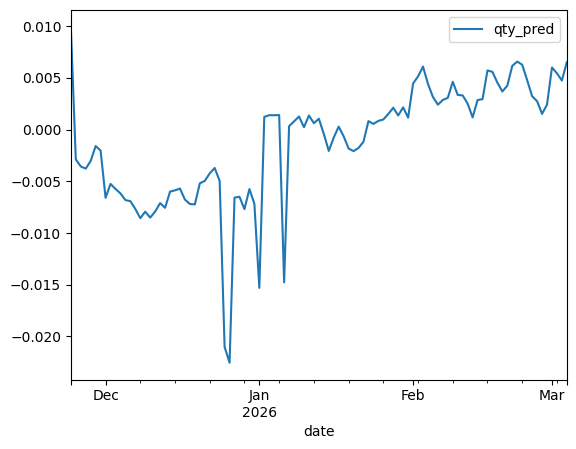

In [169]:
predictions_df.set_index(["SKU", "date"]).loc["ga1026sf"].plot()

<Axes: xlabel='date'>

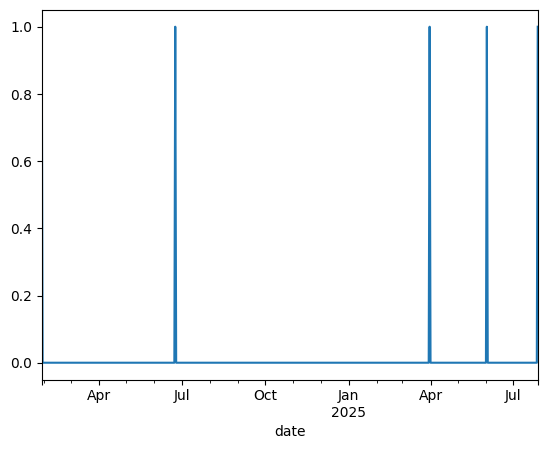

In [174]:
agg.set_index(["SKU", "date"]).loc["ga1026sf"]["qty"].plot()

In [175]:
agg

,date,SKU,qty,price_per_unit,tavg,prcp,tsun,sale_active,sale_percent,mmdd,day_of_week,month,is_holiday,is_holiday_int
0,2024-01-26,9101dx,2,1522.660000,9.0,1.2,0.0,True,0.24,01-26,4,1,False,0
1,2024-01-27,9101dx,0,1295.228583,3.0,0.0,510.0,True,0.24,01-27,5,1,False,0
2,2024-01-28,9101dx,0,1295.228583,3.7,0.0,516.0,True,0.24,01-28,6,1,False,0
3,2024-01-29,9101dx,2,1449.580000,5.5,0.0,492.0,True,0.24,01-29,0,1,False,0
4,2024-01-30,9101dx,1,1449.580000,6.1,0.0,192.0,True,0.24,01-30,1,1,False,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96658,2025-05-08,sz21032,0,74.790000,11.5,0.0,54.0,False,0.00,05-08,3,5,False,0
96659,2025-05-09,sz21032,0,74.790000,12.2,0.0,852.0,False,0.00,05-09,4,5,False,0
96660,2025-05-10,sz21032,0,74.790000,13.5,0.0,864.0,False,0.00,05-10,5,5,False,0
96661,2025-05-11,sz21032,0,74.790000,15.5,0.0,858.0,False,0.00,05-11,6,5,False,0


In [176]:
# aggregated demand forecast 

In [266]:
# aggregate sales per date overa all SKus
agg_total = (
    agg
    .groupby("date")
    .agg(
        qty=("qty", "sum"),
        tavg=("tavg", "mean"),
        prcp=("prcp", "mean"),
        tsun=("tsun", "mean"),
        sale_percent=("sale_percent", "mean"),
        is_holiday_int=("is_holiday_int", "max"),
        month=("month", "max"),
        mmdd=("mmdd", "first"),
        day_of_week=("day_of_week", "max"),
    )
    .reset_index()
)

In [267]:
agg_total

,date,qty,tavg,prcp,tsun,sale_percent,is_holiday_int,month,mmdd,day_of_week
0,2024-01-26,80,9.0,1.2,0.0,0.196923,0,1,01-26,4
1,2024-01-27,5,3.0,0.0,510.0,0.199024,0,1,01-27,5
2,2024-01-28,0,3.7,0.0,516.0,0.199024,0,1,01-28,6
3,2024-01-29,56,5.5,0.0,492.0,0.190189,0,1,01-29,0
4,2024-01-30,30,6.1,0.0,192.0,0.184000,0,1,01-30,1
...,...,...,...,...,...,...,...,...,...,...
664,2025-11-20,0,2.3,0.0,59.0,0.100000,0,11,11-20,3
665,2025-11-21,1,-1.0,0.0,136.0,0.100000,0,11,11-21,4
666,2025-11-22,0,-4.2,0.0,243.0,0.200000,0,11,11-22,5
667,2025-11-23,0,-2.6,2.5,155.0,0.200000,0,11,11-23,6


In [268]:
# aggregate sales per date overa all SKus
future_total = (
    future_df
    .groupby("date")
    .agg(
        tavg=("tavg", "mean"),
        prcp=("prcp", "mean"),
        tsun=("tsun", "mean"),
        sale_percent=("sale_percent", "mean"),
        is_holiday_int=("is_holiday_int", "max"),
        month=("month", "max"),
        mmdd=("mmdd", "first"),
        day_of_week=("day_of_week", "max"),
    )
    .reset_index()
)

In [269]:
future_total

,date,tavg,prcp,tsun,sale_percent,is_holiday_int,month,mmdd,day_of_week
0,2025-11-24,4.1,5.8,0.0,0.124107,0,11,11-24,0
1,2025-11-25,3.6,7.1,17.0,0.124107,0,11,11-25,1
2,2025-11-26,3.3,2.2,0.0,0.124107,0,11,11-26,2
3,2025-11-27,1.9,0.0,194.0,0.124107,0,11,11-27,3
4,2025-11-28,2.9,0.6,88.0,0.124107,0,11,11-28,4
...,...,...,...,...,...,...,...,...,...
96,2026-02-28,3.85,0.0,333.0,0.000000,0,2,02-28,5
97,2026-03-01,4.2,0.05,174.0,0.000000,0,3,03-01,6
98,2026-03-02,5.3,0.0,252.0,0.000000,0,3,03-02,0
99,2026-03-03,4.55,0.0,282.0,0.000000,0,3,03-03,1


In [270]:
dyn_num_cols = ["tavg", "prcp", "tsun", "sale_percent"]  # Maybe add average sale price that day or total sales
dyn_cat_cols = ["month", "is_holiday_int", "day_of_week"]

dynamic_numerical_covariates = {
    col: [] for col in dyn_num_cols
}
dynamic_categorical_covariates = {
    col: [] for col in dyn_cat_cols
}
static_categorical_covariates = {
    "SKU": []
}

In [271]:
for col in dyn_num_cols:
    hist_vals = agg_total[col].iloc[-context_len:]
    fut_vals = future_total[col].iloc[:horizon_len]
    combined = pd.concat([hist_vals, fut_vals], ignore_index=True)
    dynamic_numerical_covariates[col].append(combined.astype(float).tolist())
    # length = context_len + horizon_len

# --- dynamic categorical covariates ---
for col in dyn_cat_cols:
    hist_vals = agg_total[col].iloc[-context_len:]
    fut_vals = future_total[col].iloc[:horizon_len]
    combined = pd.concat([hist_vals, fut_vals], ignore_index=True)
    dynamic_categorical_covariates[col].append(combined.astype(int).tolist())


In [272]:
cov_forecast, ols_forecast = model.forecast_with_covariates(
    inputs=[agg_total.sort_values("date")["qty"].tolist()],
    dynamic_numerical_covariates=dynamic_numerical_covariates,
    dynamic_categorical_covariates=dynamic_categorical_covariates,
)

In [273]:
cov_forecast

[array([ 25.64793198,   9.8850976 ,   5.75214101,   6.31953622,
         11.77205899,  -4.97099988,  -8.81388683,  21.39662854,
          3.83190138,   0.37067418,   2.0338663 ,   4.58824496,
        -12.62045903, -14.8004349 ,  18.27912095,   2.14246776,
         -0.80978873,   0.49159018,   2.86901311, -12.79765991,
        -13.13461186,  19.38906307,   3.63342586,   0.76556432,
          1.04612375,   4.14661801,  -9.91598002, -11.23265717,
         22.78245422,   7.08371279,   3.67124344, -12.42102682,
        -10.97972945, -10.39923541, -11.73044444,  21.15214121,
          4.52887969,   0.57527059, -11.15886566,   7.2992101 ,
         -7.77129245,  -8.04094649,  25.25938199,  -8.21035823,
          4.58576352,   4.07969879,   6.97562455,  -9.39975434,
         -9.65541464,  23.35152166,   7.5676583 ,   3.03038658,
          2.02149696,   4.69182574,  -9.27219227,  -9.20153793,
         25.38444069,   8.64926314,   5.10859641,   5.04217747,
          7.30761063,  -8.27889985,  -7.

<Axes: xlabel='date'>

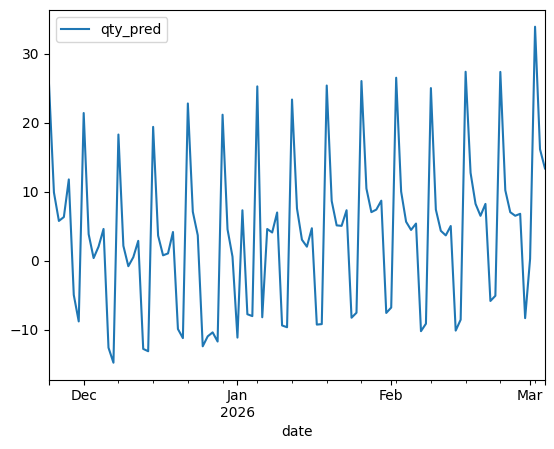

In [274]:
pd.DataFrame({"date": future_total.sort_values("date")["date"], "qty_pred": cov_forecast[0]}).set_index("date").plot()

In [226]:
# Aggregate per sku integer:

In [228]:
agg["SKU_numeric"] = agg["SKU"].str.extract(r'(\d+)').astype(int)

In [230]:
future_df["SKU_numeric"] = future_df["SKU"].str.extract(r'(\d+)').astype(int)

In [238]:
agg

,date,SKU,qty,price_per_unit,tavg,prcp,tsun,sale_active,sale_percent,mmdd,day_of_week,month,is_holiday,is_holiday_int,SKU_numeric
0,2024-01-26,9101dx,2,1522.660000,9.0,1.2,0.0,True,0.24,01-26,4,1,False,0,9101
1,2024-01-27,9101dx,0,1295.228583,3.0,0.0,510.0,True,0.24,01-27,5,1,False,0,9101
2,2024-01-28,9101dx,0,1295.228583,3.7,0.0,516.0,True,0.24,01-28,6,1,False,0,9101
3,2024-01-29,9101dx,2,1449.580000,5.5,0.0,492.0,True,0.24,01-29,0,1,False,0,9101
4,2024-01-30,9101dx,1,1449.580000,6.1,0.0,192.0,True,0.24,01-30,1,1,False,0,9101
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96658,2025-05-08,sz21032,0,74.790000,11.5,0.0,54.0,False,0.00,05-08,3,5,False,0,21032
96659,2025-05-09,sz21032,0,74.790000,12.2,0.0,852.0,False,0.00,05-09,4,5,False,0,21032
96660,2025-05-10,sz21032,0,74.790000,13.5,0.0,864.0,False,0.00,05-10,5,5,False,0,21032
96661,2025-05-11,sz21032,0,74.790000,15.5,0.0,858.0,False,0.00,05-11,6,5,False,0,21032


In [275]:
# aggregate sales per date for each unique SKU integer
agg_total = (
    agg
    .groupby(["SKU_numeric", "date"])
    .agg(
        qty=("qty", "sum"),
        tavg=("tavg", "mean"),
        prcp=("prcp", "mean"),
        tsun=("tsun", "mean"),
        sale_percent=("sale_percent", "mean"),
        is_holiday_int=("is_holiday_int", "max"),
        month=("month", "max"),
        mmdd=("mmdd", "first"),
        day_of_week=("day_of_week", "max"),
    )
    .reset_index()
)

In [276]:
agg_total

,SKU_numeric,date,qty,tavg,prcp,tsun,sale_percent,is_holiday_int,month,mmdd,day_of_week
0,1011,2025-04-08,1,8.9,0.0,714.0,0.00,0,4,04-08,1
1,1011,2025-04-09,0,10.0,0.0,708.0,0.00,0,4,04-09,2
2,1011,2025-04-10,0,9.6,0.0,720.0,0.00,0,4,04-10,3
3,1011,2025-04-11,0,11.4,0.0,744.0,0.00,0,4,04-11,4
4,1011,2025-04-12,0,15.0,0.0,702.0,0.00,0,4,04-12,5
...,...,...,...,...,...,...,...,...,...,...,...
74371,100382,2024-12-07,0,5.5,1.4,0.0,0.12,0,12,12-07,5
74372,100382,2024-12-08,0,3.7,0.5,0.0,0.12,0,12,12-08,6
74373,100382,2024-12-09,0,3.5,0.0,0.0,0.12,0,12,12-09,0
74374,100382,2024-12-10,0,3.1,0.0,0.0,0.12,0,12,12-10,1


In [277]:
# aggregate sales per date for each unique SKU integer
future_total = (
    future_df
    .groupby(["SKU_numeric", "date"])
    .agg(
        tavg=("tavg", "mean"),
        prcp=("prcp", "mean"),
        tsun=("tsun", "mean"),
        sale_percent=("sale_percent", "mean"),
        is_holiday_int=("is_holiday_int", "max"),
        month=("month", "max"),
        mmdd=("mmdd", "first"),
        day_of_week=("day_of_week", "max"),
    )
    .reset_index()
)

In [278]:
all_skus = agg_total["SKU_numeric"].unique().tolist()

In [279]:
dyn_num_cols = ["tavg", "prcp", "tsun", "sale_percent"]  # Maybe add average sale price that day or total sales
dyn_cat_cols = ["month", "is_holiday_int", "day_of_week"]

inputs = []   # (B, context_len)
dynamic_numerical_covariates = {
    col: [] for col in dyn_num_cols
}
dynamic_categorical_covariates = {
    col: [] for col in dyn_cat_cols
}
static_categorical_covariates = {
    "SKU_numeric": []
}

In [280]:
for sku in all_skus:
        hist_sku = (
            agg_total[agg_total["SKU_numeric"] == sku]
            .sort_values("date")
            .reset_index(drop=True)
        )
        fut_sku = (
            future_total[future_total["SKU_numeric"] == sku]
            .sort_values("date")
            .reset_index(drop=True)
        )

        # --- target history: qty ---
        y_hist = hist_sku["qty"].values
        inputs.append(y_hist[-context_len:].tolist())  # (context_len,)

        # --- dynamic numerical covariates ---
        for col in dyn_num_cols:
            hist_vals = hist_sku[col].iloc[-context_len:]
            fut_vals = fut_sku[col].iloc[:horizon_len]
            combined = pd.concat([hist_vals, fut_vals], ignore_index=True)
            dynamic_numerical_covariates[col].append(combined.astype(float).tolist())
            # length = context_len + horizon_len

        # --- dynamic categorical covariates ---
        for col in dyn_cat_cols:
            hist_vals = hist_sku[col].iloc[-context_len:]
            fut_vals = fut_sku[col].iloc[:horizon_len]
            combined = pd.concat([hist_vals, fut_vals], ignore_index=True)
            dynamic_categorical_covariates[col].append(combined.astype(int).tolist())
            # length = context_len + horizon_len

        # --- static covariates ---
        static_categorical_covariates["SKU_numeric"].append(sku)

In [281]:
cov_forecast, ols_forecast = model.forecast_with_covariates(
    inputs=inputs,
    dynamic_numerical_covariates=dynamic_numerical_covariates,
    dynamic_categorical_covariates=dynamic_categorical_covariates,
    static_numerical_covariates={},
    static_categorical_covariates=static_categorical_covariates,
)

In [282]:
cov_forecast

[array([ 1.09171713e-02, -9.50066285e-03, -1.22431955e-02, -7.63726295e-03,
        -1.29654405e-02,  2.00023119e-03,  7.33550236e-03, -1.03258395e-02,
        -1.84011920e-02, -3.04174623e-02, -2.14029601e-02, -1.78646817e-02,
        -1.31017269e-02, -5.80708909e-03, -8.07496313e-03, -2.39923345e-02,
        -3.52683085e-02, -2.49512235e-02, -2.43352622e-02, -1.61171075e-02,
        -8.06692375e-03, -1.27450939e-02, -2.03790049e-02, -2.96584384e-02,
        -2.15182291e-02, -2.04305964e-02, -4.57988062e-03,  1.52200691e-04,
        -3.04744908e-04, -1.02079007e-02, -2.34608436e-02, -6.39213907e-02,
        -6.43193789e-02, -4.94219441e-03, -3.56907390e-03, -9.61979291e-03,
        -2.13792939e-02, -3.06136279e-02, -4.60139768e-02, -2.08291721e-03,
         6.22916292e-03,  9.86601505e-03,  5.62058853e-03, -5.58286336e-02,
        -2.01956436e-02, -9.51794781e-03, -6.52658955e-03, -1.16133982e-03,
         6.23923159e-03,  7.97624758e-05, -9.34056368e-03, -1.91507638e-02,
        -8.9

In [283]:
results = []
for i, sku in enumerate(all_skus):
    sku_future_dates = (
        future_total[future_total["SKU_numeric"] == sku]
        .sort_values("date")["date"]
        .iloc[:horizon_len]
        .reset_index(drop=True)
    )
    y_hat = cov_forecast[i]  # length = horizon_len
    res_df = pd.DataFrame(
        {
            "SKU_numeric": sku,
            "date": sku_future_dates,
            "qty_pred": y_hat,
        }
    )
    results.append(res_df)

predictions_df = pd.concat(results, ignore_index=True)

In [284]:
predictions_df

,SKU_numeric,date,qty_pred
0,1011,2025-11-24,0.010917
1,1011,2025-11-25,-0.009501
2,1011,2025-11-26,-0.012243
3,1011,2025-11-27,-0.007637
4,1011,2025-11-28,-0.012965
...,...,...,...
17064,100382,2026-02-28,-0.047426
17065,100382,2026-03-01,-0.024157
17066,100382,2026-03-02,0.064940
17067,100382,2026-03-03,0.007107


<Axes: xlabel='date'>

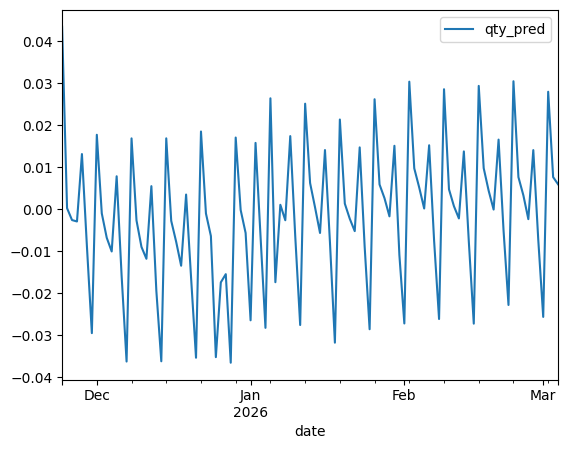

In [286]:
predictions_df.set_index(["SKU_numeric", "date"]).loc[1026].plot()

In [288]:
agg_total

,SKU_numeric,date,qty,tavg,prcp,tsun,sale_percent,is_holiday_int,month,mmdd,day_of_week
0,1011,2025-04-08,1,8.9,0.0,714.0,0.00,0,4,04-08,1
1,1011,2025-04-09,0,10.0,0.0,708.0,0.00,0,4,04-09,2
2,1011,2025-04-10,0,9.6,0.0,720.0,0.00,0,4,04-10,3
3,1011,2025-04-11,0,11.4,0.0,744.0,0.00,0,4,04-11,4
4,1011,2025-04-12,0,15.0,0.0,702.0,0.00,0,4,04-12,5
...,...,...,...,...,...,...,...,...,...,...,...
74371,100382,2024-12-07,0,5.5,1.4,0.0,0.12,0,12,12-07,5
74372,100382,2024-12-08,0,3.7,0.5,0.0,0.12,0,12,12-08,6
74373,100382,2024-12-09,0,3.5,0.0,0.0,0.12,0,12,12-09,0
74374,100382,2024-12-10,0,3.1,0.0,0.0,0.12,0,12,12-10,1


In [287]:
agg_total["qty"].describe()

count    74376.000000
mean         0.129007
std          0.717129
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         30.000000
Name: qty, dtype: float64

In [ ]:
# Analysis

In [ ]:
df["Preeis pro Einheit €"] = df["Gesamtpreis €"] / df["Auftragspositionen/Menge"]

In [ ]:
df

In [ ]:
df.groupby("SKU")["Preeis pro Einheit €"].std()

In [ ]:
df[df["SKU"] == "9101dx"]